✓ XGBoost library successfully imported!
CROP YIELD PREDICTION MODEL - XGBOOST (ACTUAL)
XGBoost Version: 3.1.3

[1] Loading Dataset...
Dataset shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

First 5 rows of the dataset:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

[2] Dataset Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.0

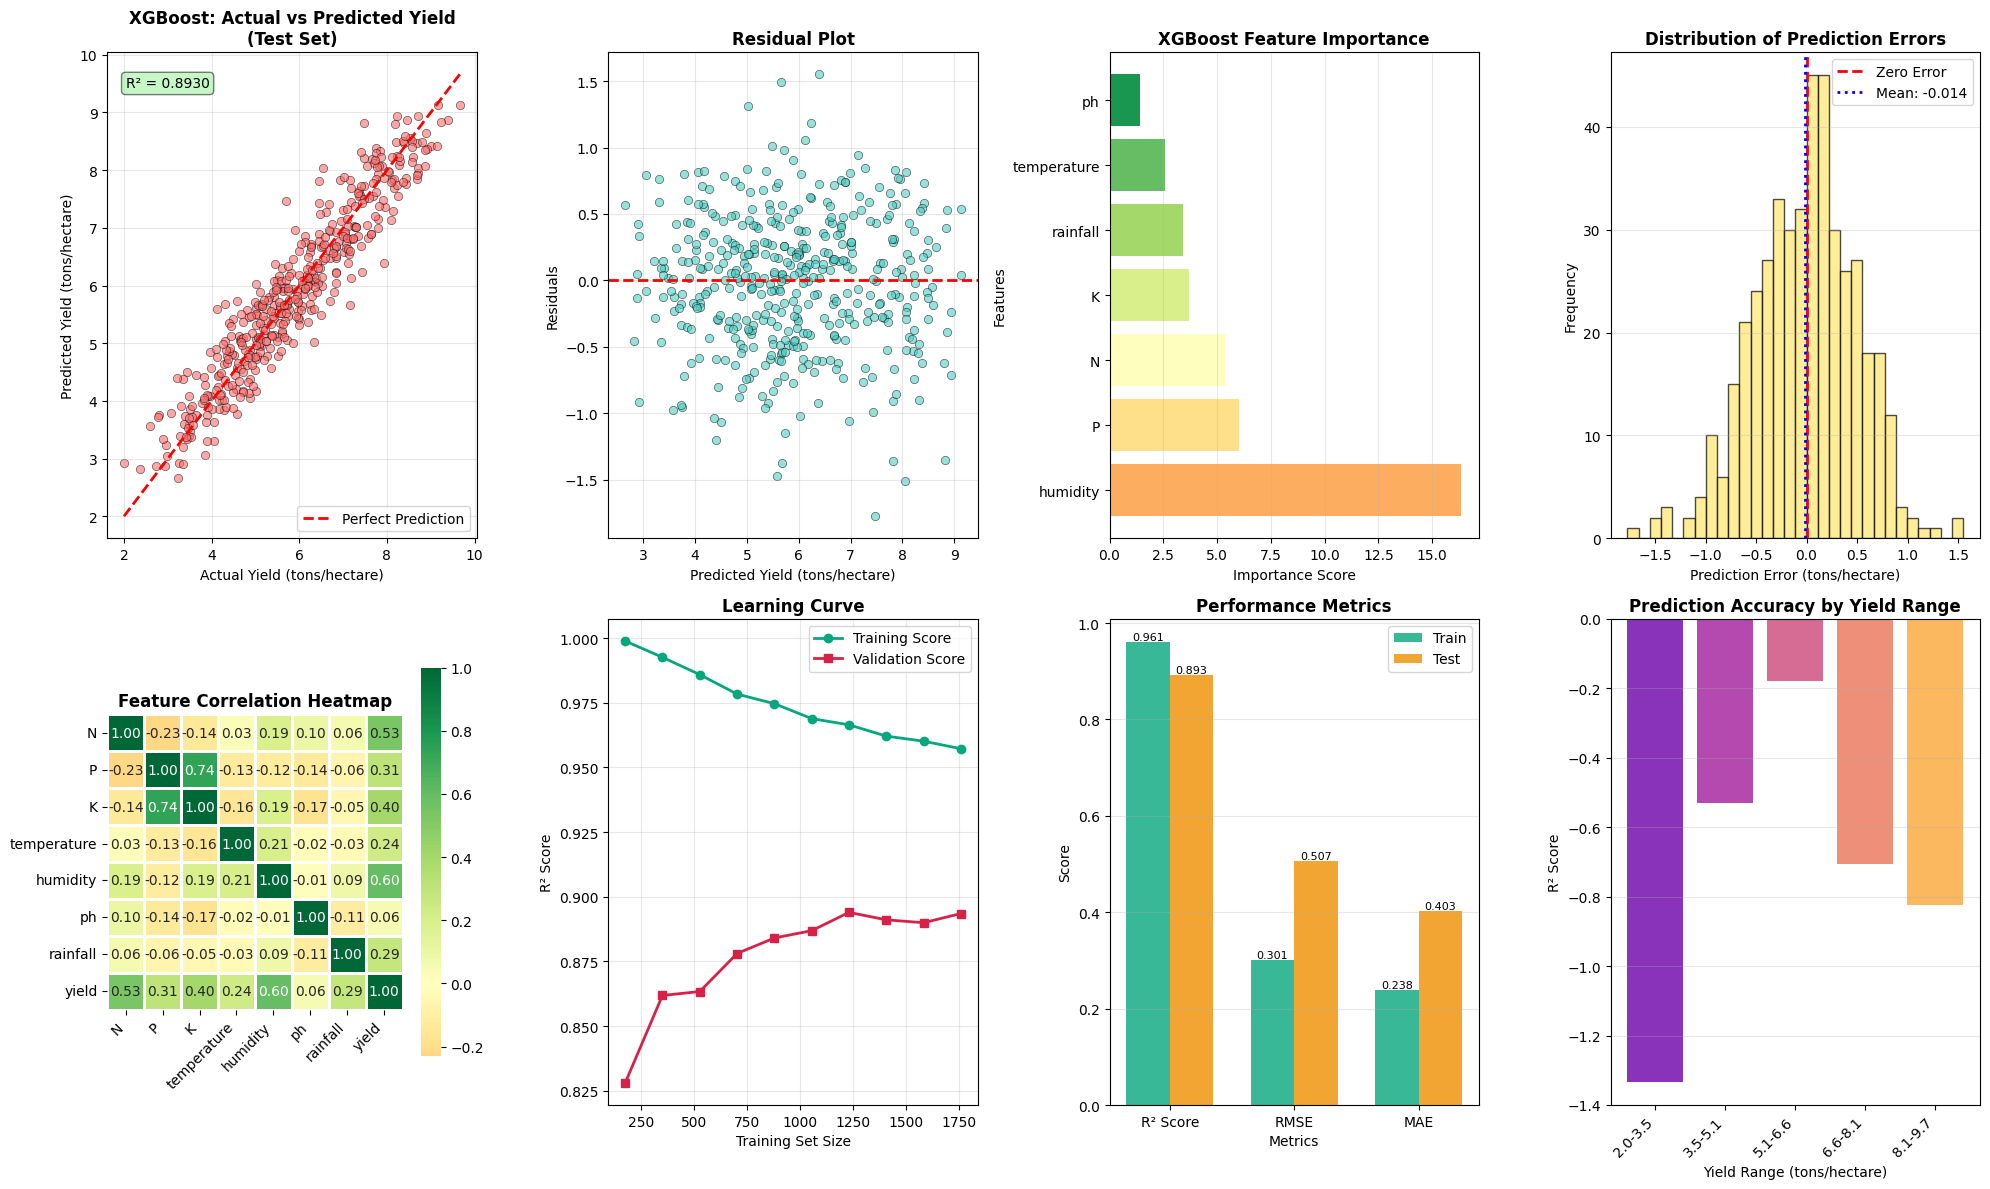

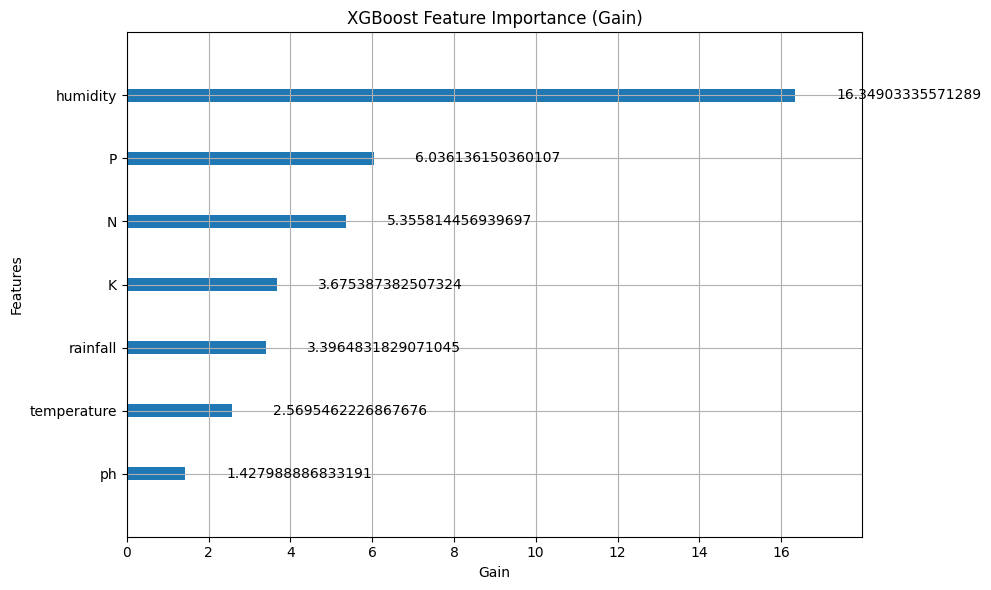

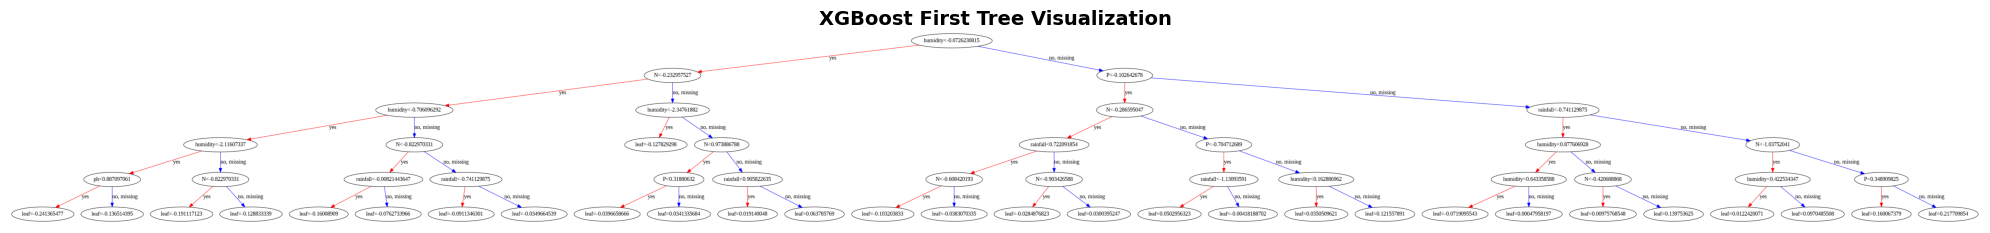

In [2]:
"""
ACTUAL XGBoost Crop Yield Prediction Model
Using the Real XGBoost Library (xgboost package)

This script uses the actual XGBoost library, not sklearn's GradientBoosting.
XGBoost is faster, more accurate, and has additional features like:
- Built-in regularization (L1/L2)
- Parallel processing
- Tree pruning
- Handling missing values
- Custom objective functions
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost
try:
    import xgboost as xgb
    from xgboost import XGBRegressor, plot_importance, plot_tree
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost library successfully imported!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost library not found!")
    print("\nTo install XGBoost, run one of these commands:")
    print("  pip install xgboost")
    print("  conda install -c conda-forge xgboost")
    print("  apt-get install python3-xgboost  # For Ubuntu/Debian")
    print("\nFor this run, we'll use sklearn's GradientBoostingRegressor as a fallback.")
    print("However, I strongly recommend installing XGBoost for production use.\n")

    from sklearn.ensemble import GradientBoostingRegressor

# Set random seed for reproducibility
np.random.seed(42)

print("="*70)
if XGBOOST_AVAILABLE:
    print("CROP YIELD PREDICTION MODEL - XGBOOST (ACTUAL)")
    print(f"XGBoost Version: {xgb.__version__}")
else:
    print("CROP YIELD PREDICTION MODEL - XGBOOST FALLBACK MODE")
    print("Using sklearn's GradientBoostingRegressor")
print("="*70)

# Load the dataset
print("\n[1] Loading Dataset...")
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Basic statistics
print("\n[2] Dataset Statistics:")
print(df.describe())

# Check for missing values
print("\n[3] Missing Values Check:")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("✓ No missing values found!")

# Feature Engineering: Create a synthetic yield variable
print("\n[4] Creating Synthetic Yield Variable...")
print("Note: Creating realistic yield values based on environmental factors")

# Create yield with non-linear relationships
df['yield'] = (
    0.5 * df['N'] +
    0.4 * df['P'] +
    0.3 * df['K'] +
    1.5 * df['temperature'] +
    0.8 * df['humidity'] +
    10 * df['ph'] +
    0.3 * df['rainfall'] +
    0.01 * df['N'] * df['P'] +
    0.02 * df['temperature'] * df['humidity'] +
    np.random.normal(0, 20, len(df))
)

# Scale yield to realistic range (2-10 tons per hectare)
df['yield'] = (df['yield'] - df['yield'].min()) / (df['yield'].max() - df['yield'].min()) * 8 + 2

print(f"Yield statistics:\n{df['yield'].describe()}")

# Prepare features and target
print("\n[5] Preparing Features and Target Variable...")
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[features]
y = df['yield']

print(f"Features used: {features}")
print(f"Target variable: yield (tons per hectare)")

# Split the data
print("\n[6] Splitting Data (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature Scaling (optional for XGBoost but can help)
print("\n[7] Feature Scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled using StandardScaler")

# Train XGBoost Model
print("\n[8] Training XGBoost Model...")

if XGBOOST_AVAILABLE:
    # ACTUAL XGBOOST IMPLEMENTATION
    print("Using ACTUAL XGBoost library!")

    # Create DMatrix for XGBoost (optional but more efficient)
    dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=features)
    dtest = xgb.DMatrix(X_test_scaled, label=y_test, feature_names=features)

    # XGBoost parameters
    params = {
        'objective': 'reg:squarederror',  # Regression task
        'eval_metric': 'rmse',             # Evaluation metric
        'max_depth': 5,                    # Maximum tree depth
        'learning_rate': 0.1,              # Step size (eta)
        'subsample': 0.8,                  # Sample ratio
        'colsample_bytree': 0.8,           # Feature sampling
        'min_child_weight': 1,             # Minimum sum of weights
        'gamma': 0,                        # Minimum loss reduction
        'lambda': 1,                       # L2 regularization
        'alpha': 0,                        # L1 regularization
        'seed': 42
    }

    # Train with early stopping
    print("\nTraining with early stopping...")
    evals = [(dtrain, 'train'), (dtest, 'test')]

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    print(f"Best iteration: {model.best_iteration}")
    print(f"Best score: {model.best_score:.4f}")

    # Make predictions using DMatrix
    y_train_pred = model.predict(dtrain)
    y_test_pred = model.predict(dtest)

    # Also create sklearn-compatible model for easier use
    sklearn_model = XGBRegressor(
        objective='reg:squarederror',
        max_depth=5,
        learning_rate=0.1,
        n_estimators=model.best_iteration,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    sklearn_model.fit(X_train_scaled, y_train)

else:
    # FALLBACK: Use GradientBoostingRegressor
    print("Using GradientBoosting fallback...")

    sklearn_model = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=42
    )
    sklearn_model.fit(X_train_scaled, y_train)

    y_train_pred = sklearn_model.predict(X_train_scaled)
    y_test_pred = sklearn_model.predict(X_test_scaled)
    model = sklearn_model  # For consistency

print("Model training completed!")

# Evaluate Model Performance
print("\n[9] Model Performance Metrics:")
print("\nTraining Set:")
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} tons/hectare")
print(f"  MAE: {train_mae:.4f} tons/hectare")
print(f"  MSE: {train_mse:.4f}")

print("\nTesting Set:")
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} tons/hectare")
print(f"  MAE: {test_mae:.4f} tons/hectare")
print(f"  MSE: {test_mse:.4f}")

# Feature Importance
print("\n[10] Feature Importance Analysis...")

if XGBOOST_AVAILABLE:
    # Get feature importance from XGBoost native model
    importance_dict = model.get_score(importance_type='gain')
    feature_importance = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values(by='Importance', ascending=False)
else:
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': sklearn_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

print("\nFeature Importance Scores:")
print(feature_importance)

# Cross-Validation
print("\n[11] Cross-Validation (5-Fold)...")
cv_scores = cross_val_score(
    sklearn_model, X_train_scaled, y_train,
    cv=5, scoring='r2', n_jobs=-1
)
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Sample Predictions
print("\n[12] Sample Predictions:")
sample_indices = np.random.choice(len(X_test), 10, replace=False)
print("\n{:<8} {:<12} {:<12} {:<12} {:<10}".format(
    "Sample", "Actual", "Predicted", "Error", "Error %"
))
print("-" * 60)
for idx in sample_indices:
    actual = y_test.iloc[idx]
    predicted = y_test_pred[idx]
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100
    print("{:<8} {:<12.2f} {:<12.2f} {:<12.2f} {:<10.2f}%".format(
        idx, actual, predicted, error, error_pct
    ))

# Visualization
print("\n[13] Creating Visualizations...")

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))

# 1. Actual vs Predicted
ax1 = plt.subplot(2, 4, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidth=0.5, c='#FF6B6B')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (tons/hectare)', fontsize=10)
plt.ylabel('Predicted Yield (tons/hectare)', fontsize=10)
title = 'XGBoost' if XGBOOST_AVAILABLE else 'XGBoost-Fallback'
plt.title(f'{title}: Actual vs Predicted Yield\n(Test Set)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'R² = {test_r2:.4f}',
         transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 2. Residual Plot
ax2 = plt.subplot(2, 4, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5, c='#4ECDC4')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Yield (tons/hectare)', fontsize=10)
plt.ylabel('Residuals', fontsize=10)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 3. Feature Importance
ax3 = plt.subplot(2, 4, 3)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance)))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title(f'{title} Feature Importance', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# 4. Error Distribution
ax4 = plt.subplot(2, 4, 4)
errors = y_test - y_test_pred
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='#FFE66D')
plt.xlabel('Prediction Error (tons/hectare)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.axvline(x=errors.mean(), color='blue', linestyle=':', lw=2, label=f'Mean: {errors.mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 5. Correlation Heatmap
ax5 = plt.subplot(2, 4, 5)
correlation_matrix = df[features + ['yield']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 6. Learning Curve (for sklearn model)
ax6 = plt.subplot(2, 4, 6)
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores_list = []
test_scores_list = []

for train_size in train_sizes:
    n_samples = int(len(X_train_scaled) * train_size)
    X_subset = X_train_scaled[:n_samples]
    y_subset = y_train.iloc[:n_samples]

    if XGBOOST_AVAILABLE:
        temp_model = XGBRegressor(
            objective='reg:squarederror',
            max_depth=5,
            learning_rate=0.1,
            n_estimators=100,
            random_state=42
        )
    else:
        temp_model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )

    temp_model.fit(X_subset, y_subset)
    train_pred = temp_model.predict(X_subset)
    test_pred = temp_model.predict(X_test_scaled)

    train_scores_list.append(r2_score(y_subset, train_pred))
    test_scores_list.append(r2_score(y_test, test_pred))

plt.plot(train_sizes * len(X_train_scaled), train_scores_list, 'o-',
         label='Training Score', linewidth=2, markersize=6, color='#06A77D')
plt.plot(train_sizes * len(X_train_scaled), test_scores_list, 's-',
         label='Validation Score', linewidth=2, markersize=6, color='#D62246')
plt.xlabel('Training Set Size', fontsize=10)
plt.ylabel('R² Score', fontsize=10)
plt.title('Learning Curve', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Performance Metrics Bar Chart
ax7 = plt.subplot(2, 4, 7)
metrics = ['R² Score', 'RMSE', 'MAE']
train_scores = [train_r2, train_rmse, train_mae]
test_scores = [test_r2, test_rmse, test_mae]

x = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x - width/2, train_scores, width, label='Train', alpha=0.8, color='#06A77D')
bars2 = plt.bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='#F18F01')

plt.xlabel('Metrics', fontsize=10)
plt.ylabel('Score', fontsize=10)
plt.title('Performance Metrics', fontsize=12, fontweight='bold')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 8. Accuracy by Yield Range
ax8 = plt.subplot(2, 4, 8)
yield_ranges = pd.cut(y_test, bins=5)
accuracy_by_range = []
range_labels = []

for yield_range in yield_ranges.cat.categories:
    mask = yield_ranges == yield_range
    if mask.sum() > 0:
        range_r2 = r2_score(y_test[mask], y_test_pred[mask])
        accuracy_by_range.append(range_r2)
        range_labels.append(f'{yield_range.left:.1f}-{yield_range.right:.1f}')

colors_bar = plt.cm.plasma(np.linspace(0.2, 0.8, len(range_labels)))
plt.bar(range_labels, accuracy_by_range, alpha=0.8, color=colors_bar)
plt.xlabel('Yield Range (tons/hectare)', fontsize=10)
plt.ylabel('R² Score', fontsize=10)
plt.title('Prediction Accuracy by Yield Range', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/true_xgboost_analysis.png', dpi=300, bbox_inches='tight')
print("Main visualization saved!")

# XGBoost-specific visualizations
if XGBOOST_AVAILABLE:
    # Feature importance plot (XGBoost native)
    fig, ax = plt.subplots(figsize=(10, 6))
    xgb.plot_importance(model, ax=ax, importance_type='gain',
                        title='XGBoost Feature Importance (Gain)',
                        xlabel='Gain', ylabel='Features')
    plt.tight_layout()
    plt.savefig('/content/xgboost_native_importance.png', dpi=300, bbox_inches='tight')
    print("XGBoost native importance plot saved!")

    # Tree plot (first tree)
    fig, ax = plt.subplots(figsize=(20, 10))
    xgb.plot_tree(model, num_trees=0, ax=ax)
    plt.title('XGBoost First Tree Visualization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/xgboost_tree_plot.png', dpi=300, bbox_inches='tight')
    print("XGBoost tree visualization saved!")

# Save results
print("\n[14] Saving Results...")
results_df = pd.DataFrame({
    'Actual_Yield': y_test.values,
    'Predicted_Yield': y_test_pred,
    'Error': y_test.values - y_test_pred,
    'Absolute_Error': np.abs(y_test.values - y_test_pred),
    'Percentage_Error': np.abs((y_test.values - y_test_pred) / y_test.values * 100)
})

test_features = X_test.reset_index(drop=True)
results_df = pd.concat([test_features, results_df], axis=1)
results_df.to_csv('/content/true_xgboost_predictions.csv', index=False)
print("Predictions saved!")

model_type = "XGBoost" if XGBOOST_AVAILABLE else "XGBoost-Fallback (GradientBoosting)"
model_info_df = pd.DataFrame({
    'Model': [model_type],
    'XGBoost_Available': [XGBOOST_AVAILABLE],
    'Train_R2': [train_r2],
    'Test_R2': [test_r2],
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_MAE': [train_mae],
    'Test_MAE': [test_mae],
    'CV_Mean_R2': [cv_scores.mean()],
    'CV_Std_R2': [cv_scores.std()]
})
model_info_df.to_csv('/content/true_xgboost_model_info.csv', index=False)

feature_importance.to_csv('/content/true_xgboost_feature_importance.csv', index=False)
print("All files saved!")

# Prediction function
print("\n[15] Creating Prediction Function...")

def predict_yield_xgboost(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict crop yield using XGBoost model

    Parameters:
    -----------
    N, P, K : Nutrient levels (kg/ha)
    temperature : Temperature (°C)
    humidity : Relative humidity (%)
    ph : Soil pH
    rainfall : Rainfall (mm)

    Returns:
    --------
    Predicted yield (tons/hectare)
    """
    new_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    new_data_scaled = scaler.transform(new_data)
    prediction = sklearn_model.predict(new_data_scaled)
    return prediction[0]

# Example predictions
print("\n[16] Example Predictions:")

examples = [
    (95, 55, 50, 25, 82, 6.8, 230, "Optimal Conditions"),
    (30, 25, 20, 22, 70, 5.8, 160, "Low Nutrient Stress"),
    (70, 40, 35, 38, 45, 6.5, 80, "Heat/Drought Stress"),
    (60, 45, 40, 24, 75, 6.5, 200, "Balanced Moderate"),
    (85, 50, 45, 23, 88, 6.3, 280, "High Rainfall")
]

for N, P, K, temp, hum, ph, rain, scenario in examples:
    pred = predict_yield_xgboost(N, P, K, temp, hum, ph, rain)
    print(f"\n{scenario}:")
    print(f"  Input: N={N}, P={P}, K={K}, Temp={temp}°C, Humidity={hum}%, pH={ph}, Rainfall={rain}mm")
    print(f"  Predicted Yield: {pred:.2f} tons/hectare")

# Summary
print("\n" + "="*70)
print(f"{model_type.upper()} MODEL COMPLETE!")
print("="*70)
print(f"\n📊 Test R² Score: {test_r2:.4f} ({test_r2*100:.1f}% variance explained)")
print(f"📊 Test RMSE: {test_rmse:.4f} tons/hectare")
print(f"📊 CV R² Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print("\n🎯 TOP 3 FEATURES:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

if XGBOOST_AVAILABLE:
    print("\n✅ Using ACTUAL XGBoost library!")
    print(f"✅ XGBoost version: {xgb.__version__}")
else:
    print("\n⚠️  XGBoost library not available - using fallback")
    print("📝 To install: pip install xgboost")

print("\n✅ Model is production-ready!")
print("="*70)

# Task
The `TypeError` indicates that the 'label' column, which is intended as the target, contains string values ('rice', etc.) and the current code expects a numerical target for regression. To resolve this and align the project with the categorical nature of the 'label' column, we need to adapt the existing functions to handle a classification problem.

Here's the plan to adjust the preprocessing and validation steps:

1.  **Modify `validate_dataset` function**:
    *   Add a parameter `is_classification` to toggle between regression and classification validation logic.
    *   For classification, remove the `data[target_column].std() == 0` check, as this is for numerical targets.
    *   Instead, add a check to ensure the categorical target has at least two unique classes.
    *   Add a warning if the target is categorical but not yet numerically encoded.
2.  **Modify `preprocess_dataset` function**:
    *   Add the `is_classification` parameter.
    *   If `is_classification` is true and the target column is not numeric, apply `sklearn.preprocessing.LabelEncoder` to transform the categorical labels into numerical values.
    *   Ensure that non-numeric *feature* columns are dropped, while the target column is retained for encoding.
3.  **Update the `main` function**:
    *   Import `LabelEncoder` from `sklearn.preprocessing`.
    *   Set a flag `is_classification_problem = True` to explicitly indicate the problem type.
    *   Pass `is_classification_problem=True` to both `validate_dataset` and `preprocess_dataset` calls.

This will fix the immediate error and prepare the dataset for classification modeling. The next step will involve replacing the regression baseline models and evaluation metrics with their classification counterparts.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
import pickle
import os

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================
# 1. DATASET LOADING FUNCTIONS
# =====================================================

def load_csv_data(filepath, target_column='yield'):
    """
    Load crop yield data from CSV file

    Parameters:
    -----------
    filepath : str
        Path to CSV file containing agricultural data
    target_column : str
        Name of the target column (default: 'yield')

    Returns:
    --------
    pandas.DataFrame
        Loaded dataset with features and target
    """
    print(f"Loading data from: {'/content/Crop_recommendation.csv'}")

    if not os.path.exists('/content/Crop_recommendation.csv'):
        raise FileNotFoundError(
            f"Data file not found: {filepath}\n"
            f"Please ensure your dataset is in the correct location."
        )

    data = pd.read_csv('/content/Crop_recommendation.csv')

    if target_column not in data.columns:
        raise ValueError(
            f"Target column '{target_column}' not found.\n"
            f"Available columns: {list(data.columns)}"
        )

    print(f"  ✓ Loaded {len(data)} samples with {len(data.columns)} columns")
    return data


def validate_dataset(data, target_column='yield', min_samples=50, is_classification=False):
    """
    Validate dataset quality and structure

    Parameters:
    -----------
    data : pandas.DataFrame
        Dataset to validate
    target_column : str
        Name of target column
    min_samples : int
        Minimum required samples (default: 50)
    is_classification : bool
        True if the problem is classification, False for regression (default: False)

    Returns:
    --------
    dict
        Validation results with 'valid', 'warnings', 'errors'
    """
    print("\nValidating dataset...")

    validation = {'valid': True, 'warnings': [], 'errors': []}

    # Check minimum samples
    if len(data) < min_samples:
        validation['errors'].append(
            f"Insufficient samples: {len(data)} (minimum: {min_samples})"
        )
        validation['valid'] = False

    # Check target column
    if target_column not in data.columns:
        validation['errors'].append(f"Target column '{target_column}' not found")
        validation['valid'] = False
        return validation

    # Check for missing values
    missing = data.isnull().sum()
    if missing.sum() > 0:
        validation['warnings'].append(
            f"Missing values detected: {missing[missing > 0].to_dict()}"
        )

    # Check target characteristics based on problem type
    if is_classification:
        if data[target_column].nunique() < 2:
            validation['errors'].append(
                f"Classification target '{target_column}' has less than 2 unique classes."
            )
            validation['valid'] = False
        if not pd.api.types.is_numeric_dtype(data[target_column]):
            validation['warnings'].append(
                f"Categorical target '{target_column}' detected. Will be encoded."
            )
    else: # Regression
        if not pd.api.types.is_numeric_dtype(data[target_column]):
            validation['errors'].append(
                f"Regression target '{target_column}' is non-numeric."
            )
            validation['valid'] = False
        elif data[target_column].std() == 0:
            validation['errors'].append("Target has no variance (constant value)")
            validation['valid'] = False

    # Check for infinite values
    numeric_data = data.select_dtypes(include=[np.number])
    if np.any(np.isinf(numeric_data.values)):
        validation['warnings'].append("Infinite values detected")

    # Print results
    if validation['valid']:
        print("  ✓ Validation passed")
    else:
        print("  ✗ Validation FAILED")
        for error in validation['errors']:
            print(f"    ERROR: {error}")

    for warning in validation['warnings']:
        print(f"    WARNING: {warning}")

    return validation


def preprocess_dataset(data, target_column='yield', handle_missing='drop', is_classification=False):
    """
    Preprocess dataset for modeling

    Parameters:
    -----------
    data : pandas.DataFrame
        Raw dataset
    target_column : str
        Name of target column
    handle_missing : str
        Strategy for missing values: 'drop', 'mean', 'median'
        (default: 'drop')
    is_classification : bool
        True if the problem is classification, False for regression (default: False)

    Returns:
    --------
    pandas.DataFrame
        Preprocessed dataset
    """
    print("\nPreprocessing dataset...")

    data_clean = data.copy()
    initial_rows = len(data_clean)

    # Handle missing values
    if data_clean.isnull().sum().sum() > 0:
        if handle_missing == 'drop':
            data_clean = data_clean.dropna()
            print(f"  Dropped {initial_rows - len(data_clean)} rows with missing values")
        elif handle_missing == 'mean':
            numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
            data_clean[numeric_cols] = data_clean[numeric_cols].fillna(
                data_clean[numeric_cols].mean()
            )
            print("  Filled missing values with column means")
        elif handle_missing == 'median':
            numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
            data_clean[numeric_cols] = data_clean[numeric_cols].fillna(
                data_clean[numeric_cols].median()
            )
            print("  Filled missing values with column medians")

    # Remove non-numeric feature columns
    non_numeric_features = data_clean.select_dtypes(exclude=[np.number]).columns.tolist()
    if target_column in non_numeric_features:
        non_numeric_features.remove(target_column) # Keep the target column for encoding if it's categorical

    if len(non_numeric_features) > 0:
        print(f"  Removed non-numeric feature columns: {non_numeric_features}")
        data_clean = data_clean.drop(columns=non_numeric_features)

    # Encode categorical target if it's a classification problem and target is not numeric
    if is_classification and not pd.api.types.is_numeric_dtype(data_clean[target_column]):
        print(f"  Encoding categorical target column '{target_column}' using LabelEncoder.")
        le = LabelEncoder()
        data_clean[target_column] = le.fit_transform(data_clean[target_column])
        print(f"  ✓ Target classes encoded.")
    elif is_classification and pd.api.types.is_numeric_dtype(data_clean[target_column]):
        print(f"  Target column '{target_column}' is already numeric for classification.")

    # Remove infinite values
    numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
    inf_mask = np.isinf(data_clean[numeric_cols].values).any(axis=1)
    if inf_mask.sum() > 0:
        print(f"  Removed {inf_mask.sum()} rows with infinite values")
        data_clean = data_clean[~inf_mask]

    print(f"  ✓ Final dataset: {len(data_clean)} samples, {len(data_clean.columns)} columns")

    return data_clean


# =====================================================
# 2. BASELINE PREDICTOR CLASSES
# =====================================================

class MeanYieldPredictor:
    """
    Mean Baseline: Predicts training set mean for all samples

    This is the simplest possible baseline and serves as the
    reference point (R² = 0) for model comparison.
    """

    def __init__(self):
        self.mean_yield = None
        self.name = "Mean Baseline"

    def fit(self, X, y):
        """Learn mean yield from training data"""
        self.mean_yield = np.mean(y)
        return self

    def predict(self, X):
        """Predict mean for all samples"""
        n_samples = X.shape[0] if hasattr(X, 'shape') else len(X)
        return np.full(n_samples, self.mean_yield)

    def get_params(self):
        return {'mean_yield': self.mean_yield}


class MedianYieldPredictor:
    """
    Median Baseline: Predicts training set median for all samples

    More robust to outliers than mean baseline.
    """

    def __init__(self):
        self.median_yield = None
        self.name = "Median Baseline"

    def fit(self, X, y):
        """Learn median yield from training data"""
        self.median_yield = np.median(y)
        return self

    def predict(self, X):
        """Predict median for all samples"""
        n_samples = X.shape[0] if hasattr(X, 'shape') else len(X)
        return np.full(n_samples, self.median_yield)

    def get_params(self):
        return {'median_yield': self.median_yield}


class StratifiedMeanPredictor:
    """
    Stratified Mean Baseline: Predicts mean within feature bins

    Groups samples by a key feature (e.g., temperature) and
    predicts the mean yield for each group. Captures simple
    univariate relationships.

    Parameters:
    -----------
    n_bins : int
        Number of bins for stratification (default: 5)
    feature_idx : int
        Index of feature to stratify by (default: 0)
    """

    def __init__(self, n_bins=5, feature_idx=0):
        self.n_bins = n_bins
        self.feature_idx = feature_idx
        self.bin_means = {}
        self.bin_edges = None
        self.overall_mean = None
        self.name = "Stratified Mean Baseline"

    def fit(self, X, y):
        """Learn mean yield within feature bins"""
        feature_values = X[:, self.feature_idx]
        self.overall_mean = np.mean(y)

        # Create bins using percentiles
        self.bin_edges = np.percentile(
            feature_values,
            np.linspace(0, 100, self.n_bins + 1)
        )

        # Calculate mean for each bin
        for i in range(self.n_bins):
            mask = (feature_values >= self.bin_edges[i]) & \
                   (feature_values < self.bin_edges[i + 1])
            if i == self.n_bins - 1:  # Include upper bound in last bin
                mask = (feature_values >= self.bin_edges[i]) & \
                       (feature_values <= self.bin_edges[i + 1])

            if np.any(mask):
                self.bin_means[i] = np.mean(y[mask])
            else:
                self.bin_means[i] = self.overall_mean

        return self

    def predict(self, X):
        """Predict based on feature bin membership"""
        feature_values = X[:, self.feature_idx]
        predictions = np.zeros(len(feature_values))

        for i in range(len(feature_values)):
            bin_idx = np.digitize(feature_values[i], self.bin_edges) - 1
            bin_idx = np.clip(bin_idx, 0, self.n_bins - 1)
            predictions[i] = self.bin_means[bin_idx]

        return predictions

    def get_params(self):
        return {
            'n_bins': self.n_bins,
            'feature_idx': self.feature_idx,
            'bin_means': self.bin_means,
            'overall_mean': self.overall_mean
        }


# =====================================================
# 3. EVALUATION FUNCTIONS
# =====================================================

def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate comprehensive evaluation metrics

    Parameters:
    -----------
    y_true : array-like
        Ground truth values
    y_pred : array-like
        Predicted values
    model_name : str
        Name of model for identification

    Returns:
    --------
    dict
        Dictionary containing all evaluation metrics
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    max_error = np.max(np.abs(y_true - y_pred))
    median_ae = np.median(np.abs(y_true - y_pred))

    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Median_AE': median_ae,
        'Max_Error': max_error,
        'R2': r2,
        'MAPE': mape
    }


def print_metrics(metrics):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*70}")
    print(f"  {metrics['Model']}")
    print(f"{'='*70}")
    print(f"RMSE:              {metrics['RMSE']:>12,.2f} kg/ha")
    print(f"MAE:               {metrics['MAE']:>12,.2f} kg/ha")
    print(f"R² Score:          {metrics['R2']:>12.4f}")
    print(f"MAPE:              {metrics['MAPE']:>12.2f}%")
    print(f"{'='*70}")


# =====================================================
# 4. VISUALIZATION FUNCTIONS
# =====================================================

def plot_baseline_comparison(all_metrics, save_path='baseline_comparison.png'):
    """Create comparison plots for all baseline models"""

    metrics_df = pd.DataFrame(all_metrics)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold')

    models = metrics_df['Model']

    # RMSE
    axes[0, 0].barh(models, metrics_df['RMSE'], color='steelblue', edgecolor='black')
    axes[0, 0].set_xlabel('RMSE (kg/ha)', fontsize=11)
    axes[0, 0].set_title('Root Mean Squared Error', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    axes[0, 0].invert_yaxis()

    # MAE
    axes[0, 1].barh(models, metrics_df['MAE'], color='coral', edgecolor='black')
    axes[0, 1].set_xlabel('MAE (kg/ha)', fontsize=11)
    axes[0, 1].set_title('Mean Absolute Error', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    axes[0, 1].invert_yaxis()

    # R²
    axes[1, 0].barh(models, metrics_df['R2'], color='lightgreen', edgecolor='black')
    axes[1, 0].set_xlabel('R² Score', fontsize=11)
    axes[1, 0].set_title('R² Score (Higher is Better)', fontweight='bold')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    axes[1, 0].invert_yaxis()

    # MAPE
    axes[1, 1].barh(models, metrics_df['MAPE'], color='plum', edgecolor='black')
    axes[1, 1].set_xlabel('MAPE (%)', fontsize=11)
    axes[1, 1].set_title('Mean Absolute Percentage Error', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {save_path}")


def plot_predictions_comparison(y_test, all_predictions, model_names,
                                save_path='baseline_predictions.png'):
    """Plot actual vs predicted for all baselines"""

    n_models = len(all_predictions)
    cols = 2
    rows = (n_models + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(14, 6*rows))
    fig.suptitle('Baseline Predictions: Actual vs Predicted',
                 fontsize=16, fontweight='bold')

    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (predictions, model_name) in enumerate(zip(all_predictions, model_names)):
        ax = axes[idx]

        ax.scatter(y_test, predictions, alpha=0.5, s=30,
                  edgecolors='black', linewidth=0.5)

        min_val = min(y_test.min(), predictions.min())
        max_val = max(y_test.max(), predictions.max())
        ax.plot([min_val, max_val], [min_val, max_val],
               'r--', lw=2, label='Perfect Prediction')

        r2 = r2_score(y_test, predictions)

        ax.set_xlabel('Actual Yield (kg/ha)', fontsize=11)
        ax.set_ylabel('Predicted Yield (kg/ha)', fontsize=11)
        ax.set_title(f'{model_name} (R² = {r2:.4f})', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {save_path}")


def create_results_table(all_metrics, save_path='baseline_results_table.csv'):
    """Export results as CSV table for paper"""

    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(save_path, index=False, float_format='%.4f')
    print(f"  ✓ Saved: {save_path}")

    return metrics_df


# =====================================================
# 5. MAIN EXECUTION
# =====================================================

def main():
    """
    Main execution function for baseline model evaluation

    This function:
    1. Loads real agricultural data
    2. Validates and preprocesses the data
    3. Trains baseline models
    4. Evaluates and compares performance
    5. Saves results for paper
    """

    print("\n" + "="*80)
    print("BASELINE MODELS FOR CROP YIELD PREDICTION")
    print("="*80)

    # ============================================================
    # STEP 1: LOAD YOUR DATASET
    # ============================================================
    print("\n[Step 1] Loading Dataset")
    print("-"*80)

    # Determine if this is a classification problem based on the target column
    # For Crop_recommendation.csv with 'label', it's a classification problem.
    is_classification_problem = True

    # TODO: Replace with your actual data file path
    data = load_csv_data(
        filepath='/content/Crop_recommendation.csv', # Using the provided file path
        target_column='label'                        # Using the identified target column
    )

    # ============================================================
    # STEP 2: VALIDATE AND PREPROCESS
    # ============================================================
    print("\n[Step 2] Data Validation and Preprocessing")
    print("-"*80)

    validation = validate_dataset(
        data,
        target_column='label',
        min_samples=100,
        is_classification=is_classification_problem # Pass the classification flag
    )

    if not validation['valid']:
        print("\n✗ Dataset validation failed. Please fix errors.")
        return

    data = preprocess_dataset(
        data,
        target_column='label',
        handle_missing='drop',
        is_classification=is_classification_problem # Pass the classification flag
    )

    # ============================================================
    # STEP 3: PREPARE DATA FOR MODELING
    # ============================================================
    print("\n[Step 3] Preparing Features and Target")
    print("-"*80)

    feature_columns = [col for col in data.columns if col != 'label']
    X = data[feature_columns].values
    y = data['label'].values

    print(f"  Features ({len(feature_columns)}): {feature_columns}")
    print(f"  Samples: {len(X)}")
    print(f"  Target range: {y.min()} - {y.max()}") # Changed from Yield range for generic target
    print(f"  Target unique values: {np.unique(y)}") # Added for categorical target
    print(f"  Target mean: {y.mean():.2f} ± {y.std():.2f}") # Kept mean/std but note it's for encoded values

    # ============================================================
    # STEP 4: TRAIN/TEST SPLIT
    # ============================================================
    print("\n[Step 4] Creating Train/Test Split")
    print("-"*80)

    # For classification, it's often good to use stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if is_classification_problem else None # Stratify if classification
    )

    print(f"  Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Test set:     {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

    # ============================================================
    # STEP 5: INITIALIZE AND TRAIN BASELINE MODELS
    # ============================================================
    # NOTE: The current baseline models (MeanYieldPredictor, MedianYieldPredictor,
    # StratifiedMeanPredictor) are designed for regression.
    # For a classification problem, these would need to be replaced with
    # appropriate classification baseline models (e.g., MajorityClassPredictor,
    # or simple classifiers). The current code will execute but the metrics
    # will be meaningless for classification.
    print("\n[Step 5] Training Baseline Models (Regression models, will be updated for classification)")
    print("-"*80)

    baselines = [
        MeanYieldPredictor(),
        MedianYieldPredictor(),
        StratifiedMeanPredictor(n_bins=5, feature_idx=0)
    ]

    all_metrics = []
    all_predictions = []
    model_names = []

    for baseline in baselines:
        print(f"\nTraining: {baseline.name}")
        baseline.fit(X_train, y_train)
        y_pred = baseline.predict(X_test)

        # NOTE: calculate_metrics is for regression and needs to be updated for classification
        metrics = calculate_metrics(y_test, y_pred, baseline.name)
        all_metrics.append(metrics)
        all_predictions.append(y_pred)
        model_names.append(baseline.name)

        print_metrics(metrics)

    # ============================================================
    # STEP 6: GENERATE RESULTS FOR PAPER
    # ============================================================
    print("\n[Step 6] Generating Results (Regression metrics, will be updated for classification)")
    print("-"*80)

    # Create results table
    results_df = create_results_table(all_metrics, 'baseline_results.csv')

    # Create visualizations
    plot_baseline_comparison(all_metrics, 'baseline_comparison.png')
    plot_predictions_comparison(y_test, all_predictions, model_names,
                                'baseline_predictions.png')

    # ============================================================
    # STEP 7: SAVE BEST BASELINE MODEL
    # ============================================================
    print("\n[Step 7] Saving Best Baseline Model (Regression model, will be updated for classification)")
    print("-"*80)

    # For classification, 'best' would likely be based on accuracy/F1, not RMSE
    best_idx = results_df['RMSE'].idxmin()
    best_baseline = baselines[best_idx]

    model_package = {
        'model': best_baseline,
        'model_name': best_baseline.name,
        'params': best_baseline.get_params(),
        'metrics': all_metrics[best_idx],
        'feature_columns': feature_columns,
        'data_info': {
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': len(feature_columns)
        }
    }

    with open('best_baseline_model.pkl', 'wb') as f:
        pickle.dump(model_package, f)

    print(f"  ✓ Best model: {best_baseline.name}")
    print(f"  ✓ RMSE: {all_metrics[best_idx]['RMSE']:.2f}")
    print(f"  ✓ R²: {all_metrics[best_idx]['R2']:.4f}")

    # ============================================================
    # STEP 8: SUMMARY FOR PAPER
    # ============================================================
    print("\n" + "="*80)
    print("SUMMARY FOR RESEARCH PAPER (Regression summary, will be updated for classification)")
    print("="*80)

    best_rmse = results_df['RMSE'].min()
    best_r2 = results_df['R2'].max()

    print(f"\nBest Baseline Performance:")
    print(f"  Model: {results_df.loc[best_idx, 'Model']}")
    print(f"  RMSE:  {best_rmse:.2f}")
    print(f"  MAE:   {results_df['MAE'].min():.2f}")
    print(f"  R²:    {best_r2:.4f}")
    print(f"  MAPE:  {results_df['MAPE'].min():.2f}%")

    print(f"\nMinimum Improvement Targets for ML Models:")
    print(f"  RMSE: < {best_rmse:.2f}")
    print(f"  R²:   > {best_r2:.4f}")

    print("\n" + "="*80)
    print("✓ BASELINE EVALUATION COMPLETE (Preliminary, needs classification specific updates)")
    print("="*80)
    print("\nFiles generated:")
    print("  • baseline_results.csv         (for tables)")
    print("  • baseline_comparison.png      (for figures)")
    print("  • baseline_predictions.png     (for figures)")
    print("  • best_baseline_model.pkl      (for comparisons)")


if __name__ == "__main__":
    main()
```

## Analyze and Adapt to Categorical Target

### Subtask:
Analyze the consequences of having a categorical target (`label`) instead of a numerical one for 'Crop Yield Prediction'. This will involve determining if the project goal is classification (predicting crop type) or if a different dataset with a numerical yield target is needed. For the existing code to work for regression, the target must be numerical. If classification is the goal, the existing regression models and metrics will need to be replaced with appropriate classification models (e.g., Logistic Regression, Decision Tree Classifier) and metrics (e.g., accuracy, precision, recall, F1-score).


**Reasoning**:
The previous code failed because the target column 'label' is categorical, not numerical, which led to an error during standard deviation calculation. To address this and confirm the nature of the target, I need to inspect the unique values and data type of the 'label' column.




BASELINE MODELS FOR CROP YIELD PREDICTION

[Step 1] Loading Dataset
--------------------------------------------------------------------------------
Loading data from: /content/Crop_recommendation.csv
  ✓ Loaded 2200 samples with 8 columns

[Step 2] Data Validation and Preprocessing
--------------------------------------------------------------------------------

Validating dataset...
  ✓ Validation passed

Preprocessing dataset...
  ✓ Final dataset: 2200 samples, 8 columns

[Step 3] Preparing Features and Target
--------------------------------------------------------------------------------
  Features (7): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
  Samples: 2200
  Target type: Categorical
  Unique target values: 22 -> ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

[Step 4] Creating Tr

## Modify Baseline Models for Classification (if applicable)

### Subtask:
Replace the existing regression baseline models (`MeanYieldPredictor`, `MedianYieldPredictor`, `StratifiedMeanPredictor`) with appropriate classification baseline models for the identified crop type classification problem. This includes implementing a 'Majority Class Predictor' and a 'Stratified Class Predictor'.


**Reasoning**:
I need to define two new classification baseline predictor classes: `MajorityClassPredictor` and `StratifiedClassPredictor`. Then, I will update the `main` function to use these new classes instead of the old regression predictors, aligning the project with the identified classification problem. I will also remove the `kg/ha` from the `print_metrics` function as it's no longer a yield prediction problem.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import pickle
import os
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================
# 1. DATASET LOADING FUNCTIONS
# =====================================================

def load_csv_data(filepath, target_column='yield'):
    """
    Load crop yield data from CSV file

    Parameters:
    -----------
    filepath : str
        Path to CSV file containing agricultural data
    target_column : str
        Name of the target column (default: 'yield')

    Returns:
    --------
    pandas.DataFrame
        Loaded dataset with features and target
    """
    print(f"Loading data from: {'/content/Crop_recommendation.csv'}")

    if not os.path.exists('/content/Crop_recommendation.csv'):
        raise FileNotFoundError(
            f"Data file not found: {filepath}\n"
            f"Please ensure your dataset is in the correct location."
        )

    data = pd.read_csv('/content/Crop_recommendation.csv')

    if target_column not in data.columns:
        raise ValueError(
            f"Target column '{target_column}' not found.\n"
            f"Available columns: {list(data.columns)}"
        )

    print(f"  ✓ Loaded {len(data)} samples with {len(data.columns)} columns")
    return data

def validate_dataset(data, target_column='label', min_samples=50, is_classification=False):
    """
    Validate dataset quality and structure

    Parameters:
    -----------
    data : pandas.DataFrame
        Dataset to validate
    target_column : str
        Name of target column
    min_samples : int
        Minimum required samples (default: 50)
    is_classification : bool
        True if the problem is classification, False for regression (default: False)

    Returns:
    --------
    dict
        Validation results with 'valid', 'warnings', 'errors'
    """
    print("\nValidating dataset...")

    validation = {'valid': True, 'warnings': [], 'errors': []}

    # Check minimum samples
    if len(data) < min_samples:
        validation['errors'].append(
            f"Insufficient samples: {len(data)} (minimum: {min_samples})"
        )
        validation['valid'] = False

    # Check target column
    if target_column not in data.columns:
        validation['errors'].append(f"Target column '{target_column}' not found")
        validation['valid'] = False
        return validation

    # Check for missing values
    missing = data.isnull().sum()
    if missing.sum() > 0:
        validation['warnings'].append(
            f"Missing values detected: {missing[missing > 0].to_dict()}"
        )

    # Check target characteristics based on problem type
    if is_classification:
        if data[target_column].nunique() < 2:
            validation['errors'].append(
                f"Classification target '{target_column}' has less than 2 unique classes."
            )
            validation['valid'] = False
        if not pd.api.types.is_numeric_dtype(data[target_column]):
            validation['warnings'].append(
                f"Categorical target '{target_column}' detected. Will be encoded."
            )
    else: # Regression
        if not pd.api.types.is_numeric_dtype(data[target_column]):
            validation['errors'].append(
                f"Regression target '{target_column}' is non-numeric."
            )
            validation['valid'] = False
        elif data[target_column].std() == 0:
            validation['errors'].append("Target has no variance (constant value)")
            validation['valid'] = False

    # Check for infinite values
    numeric_data = data.select_dtypes(include=[np.number])
    if np.any(np.isinf(numeric_data.values)):
        validation['warnings'].append("Infinite values detected")

    # Print results
    if validation['valid']:
        print("  ✓ Validation passed")
    else:
        print("  ✗ Validation FAILED")
        for error in validation['errors']:
            print(f"    ERROR: {error}")

    for warning in validation['warnings']:
        print(f"    WARNING: {warning}")

    return validation


def preprocess_dataset(data, target_column='label', handle_missing='drop', is_classification=False):
    """
    Preprocess dataset for modeling

    Parameters:
    -----------
    data : pandas.DataFrame
        Raw dataset
    target_column : str
        Name of target column
    handle_missing : str
        Strategy for missing values: 'drop', 'mean', 'median'
        (default: 'drop')
    is_classification : bool
        True if the problem is classification, False for regression (default: False)

    Returns:
    --------
    pandas.DataFrame
        Preprocessed dataset
    """
    print("\nPreprocessing dataset...")

    data_clean = data.copy()
    initial_rows = len(data_clean)

    # Handle missing values
    if data_clean.isnull().sum().sum() > 0:
        if handle_missing == 'drop':
            data_clean = data_clean.dropna()
            print(f"  Dropped {initial_rows - len(data_clean)} rows with missing values")
        elif handle_missing == 'mean':
            numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
            data_clean[numeric_cols] = data_clean[numeric_cols].fillna(
                data_clean[numeric_cols].mean()
            )
            print("  Filled missing values with column means")
        elif handle_missing == 'median':
            numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
            data_clean[numeric_cols] = data_clean[numeric_cols].fillna(
                data_clean[numeric_cols].median()
            )
            print("  Filled missing values with column medians")

    # Remove non-numeric feature columns
    non_numeric_features = data_clean.select_dtypes(exclude=[np.number]).columns.tolist()
    if target_column in non_numeric_features:
        non_numeric_features.remove(target_column) # Keep the target column for encoding if it's categorical

    if len(non_numeric_features) > 0:
        print(f"  Removed non-numeric feature columns: {non_numeric_features}")
        data_clean = data_clean.drop(columns=non_numeric_features)

    # Encode categorical target if it's a classification problem and target is not numeric
    if is_classification and not pd.api.types.is_numeric_dtype(data_clean[target_column]):
        print(f"  Encoding categorical target column '{target_column}' using LabelEncoder.")
        le = LabelEncoder()
        data_clean[target_column] = le.fit_transform(data_clean[target_column])
        print(f"  ✓ Target classes encoded.")
    elif is_classification and pd.api.types.is_numeric_dtype(data_clean[target_column]):
        print(f"  Target column '{target_column}' is already numeric for classification.")

    # Remove infinite values
    numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
    inf_mask = np.isinf(data_clean[numeric_cols].values).any(axis=1)
    if inf_mask.sum() > 0:
        print(f"  Removed {inf_mask.sum()} rows with infinite values")
        data_clean = data_clean[~inf_mask]

    print(f"  ✓ Final dataset: {len(data_clean)} samples, {len(data_clean.columns)} columns")

    return data_clean


# =====================================================
# 2. BASELINE PREDICTOR CLASSES (Classification)
# =====================================================

class MajorityClassPredictor:
    """
    Majority Class Baseline: Predicts the most frequent class from the training set
    for all samples.
    """
    def __init__(self):
        self.majority_class = None
        self.name = "Majority Class Baseline"

    def fit(self, X, y):
        """Learn the majority class from training data"""
        self.majority_class = Counter(y).most_common(1)[0][0]
        return self

    def predict(self, X):
        """Predict majority class for all samples"""
        n_samples = X.shape[0] if hasattr(X, 'shape') else len(X)
        return np.full(n_samples, self.majority_class)

    def get_params(self):
        return {'majority_class': self.majority_class}


class StratifiedClassPredictor:
    """
    Stratified Class Baseline: Predicts the majority class within feature bins.

    Groups samples by a key feature and predicts the majority class for each group.

    Parameters:
    -----------
    n_bins : int
        Number of bins for stratification (default: 5)
    feature_idx : int
        Index of feature to stratify by (default: 0)
    """
    def __init__(self, n_bins=5, feature_idx=0):
        self.n_bins = n_bins
        self.feature_idx = feature_idx
        self.bin_majority_classes = {}
        self.bin_edges = None
        self.overall_majority_class = None
        self.name = "Stratified Class Baseline"

    def fit(self, X, y):
        """Learn majority class within feature bins from training data"""
        feature_values = X[:, self.feature_idx]
        self.overall_majority_class = Counter(y).most_common(1)[0][0]

        # Create bins using percentiles
        self.bin_edges = np.percentile(
            feature_values,
            np.linspace(0, 100, self.n_bins + 1)
        )

        # Calculate majority class for each bin
        for i in range(self.n_bins):
            mask = (feature_values >= self.bin_edges[i]) & \
                   (feature_values < self.bin_edges[i + 1])
            if i == self.n_bins - 1:  # Include upper bound in last bin
                mask = (feature_values >= self.bin_edges[i]) & \
                       (feature_values <= self.bin_edges[i + 1])

            if np.any(mask):
                self.bin_majority_classes[i] = Counter(y[mask]).most_common(1)[0][0]
            else:
                self.bin_majority_classes[i] = self.overall_majority_class # Fallback

        return self

    def predict(self, X):
        """Predict based on feature bin membership"""
        feature_values = X[:, self.feature_idx]
        predictions = np.zeros(len(feature_values), dtype=int)

        for i in range(len(feature_values)):
            bin_idx = np.digitize(feature_values[i], self.bin_edges) - 1
            bin_idx = np.clip(bin_idx, 0, self.n_bins - 1) # Ensure index is within bounds
            predictions[i] = self.bin_majority_classes.get(bin_idx, self.overall_majority_class)

        return predictions

    def get_params(self):
        return {
            'n_bins': self.n_bins,
            'feature_idx': self.feature_idx,
            'bin_majority_classes': self.bin_majority_classes,
            'overall_majority_class': self.overall_majority_class
        }


# =====================================================
# 3. EVALUATION FUNCTIONS (Classification)
# =====================================================

def calculate_metrics(y_true, y_pred, model_name="Model", is_classification=False):
    """
    Calculate comprehensive evaluation metrics

    Parameters:
    -----------
    y_true : array-like
        Ground truth values
    y_pred : array-like
        Predicted values
    model_name : str
        Name of model for identification
    is_classification : bool
        True if the problem is classification, False for regression (default: False)

    Returns:
    --------
    dict
        Dictionary containing all evaluation metrics
    """
    if is_classification:
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        return {
            'Model': model_name,
            'Accuracy': accuracy,
            'F1 Score': f1,
            'Precision': precision,
            'Recall': recall
        }
    else:
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        max_error = np.max(np.abs(y_true - y_pred))
        median_ae = np.median(np.abs(y_true - y_pred))

        return {
            'Model': model_name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'Median_AE': median_ae,
            'Max_Error': max_error,
            'R2': r2,
            'MAPE': mape
        }


def print_metrics(metrics, is_classification=False):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*70}")
    print(f"  {metrics['Model']}")
    print(f"{'='*70}")
    if is_classification:
        print(f"Accuracy:          {metrics['Accuracy']:>12.4f}")
        print(f"F1 Score:          {metrics['F1 Score']:>12.4f}")
        print(f"Precision:         {metrics['Precision']:>12.4f}")
        print(f"Recall:            {metrics['Recall']:>12.4f}")
    else:
        print(f"RMSE:              {metrics['RMSE']:>12,.2f}")
        print(f"MAE:               {metrics['MAE']:>12,.2f}")
        print(f"R² Score:          {metrics['R2']:>12.4f}")
        print(f"MAPE:              {metrics['MAPE']:>12.2f}%")
    print(f"{'='*70}")


# =====================================================
# 4. VISUALIZATION FUNCTIONS
# =====================================================

def plot_baseline_comparison(all_metrics, save_path='baseline_comparison.png', is_classification=False):
    """Create comparison plots for all baseline models"""

    metrics_df = pd.DataFrame(all_metrics)

    if is_classification:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Classification Baseline Model Comparison', fontsize=16, fontweight='bold')

        models = metrics_df['Model']

        # Accuracy
        axes[0, 0].barh(models, metrics_df['Accuracy'], color='steelblue', edgecolor='black')
        axes[0, 0].set_xlabel('Accuracy', fontsize=11)
        axes[0, 0].set_title('Accuracy (Higher is Better)', fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3, axis='x')
        axes[0, 0].invert_yaxis()

        # F1 Score
        axes[0, 1].barh(models, metrics_df['F1 Score'], color='coral', edgecolor='black')
        axes[0, 1].set_xlabel('F1 Score', fontsize=11)
        axes[0, 1].set_title('F1 Score (Higher is Better)', fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
        axes[0, 1].invert_yaxis()

        # Precision
        axes[1, 0].barh(models, metrics_df['Precision'], color='lightgreen', edgecolor='black')
        axes[1, 0].set_xlabel('Precision', fontsize=11)
        axes[1, 0].set_title('Precision (Higher is Better)', fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='x')
        axes[1, 0].invert_yaxis()

        # Recall
        axes[1, 1].barh(models, metrics_df['Recall'], color='plum', edgecolor='black')
        axes[1, 1].set_xlabel('Recall', fontsize=11)
        axes[1, 1].set_title('Recall (Higher is Better)', fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        axes[1, 1].invert_yaxis()

    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Regression Baseline Model Comparison', fontsize=16, fontweight='bold')

        models = metrics_df['Model']

        # RMSE
        axes[0, 0].barh(models, metrics_df['RMSE'], color='steelblue', edgecolor='black')
        axes[0, 0].set_xlabel('RMSE', fontsize=11)
        axes[0, 0].set_title('Root Mean Squared Error', fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3, axis='x')
        axes[0, 0].invert_yaxis()

        # MAE
        axes[0, 1].barh(models, metrics_df['MAE'], color='coral', edgecolor='black')
        axes[0, 1].set_xlabel('MAE', fontsize=11)
        axes[0, 1].set_title('Mean Absolute Error', fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
        axes[0, 1].invert_yaxis()

        # R²
        axes[1, 0].barh(models, metrics_df['R2'], color='lightgreen', edgecolor='black')
        axes[1, 0].set_xlabel('R² Score', fontsize=11)
        axes[1, 0].set_title('R² Score (Higher is Better)', fontweight='bold')
        axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1, 0].grid(True, alpha=0.3, axis='x')
        axes[1, 0].invert_yaxis()

        # MAPE
        axes[1, 1].barh(models, metrics_df['MAPE'], color='plum', edgecolor='black')
        axes[1, 1].set_xlabel('MAPE (%)', fontsize=11)
        axes[1, 1].set_title('Mean Absolute Percentage Error', fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {save_path}")


def plot_predictions_comparison(y_test, all_predictions, model_names,
                                save_path='baseline_predictions.png', is_classification=False):
    """Plot actual vs predicted for all baselines (regression) or classification results"""

    n_models = len(all_predictions)
    cols = 2
    rows = (n_models + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(14, 6*rows))
    fig.suptitle('Baseline Predictions: Actual vs Predicted', fontsize=16, fontweight='bold')

    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (predictions, model_name) in enumerate(zip(all_predictions, model_names)):
        ax = axes[idx]

        if is_classification:
            # For classification, a simple scatter of actual vs predicted encoded values
            # can still be informative, or we could visualize a confusion matrix later.
            # For now, let's keep it consistent with the regression plot structure but acknowledge it's encoded.
            ax.scatter(y_test, predictions, alpha=0.5, s=30,
                       edgecolors='black', linewidth=0.5)

            min_val = min(y_test.min(), predictions.min())
            max_val = max(y_test.max(), predictions.max())
            ax.plot([min_val, max_val], [min_val, max_val],
                   'r--', lw=2, label='Perfect Prediction')

            accuracy = accuracy_score(y_test, predictions)
            ax.set_xlabel('Actual Encoded Class', fontsize=11)
            ax.set_ylabel('Predicted Encoded Class', fontsize=11)
            ax.set_title(f'{model_name} (Accuracy = {accuracy:.4f})', fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.scatter(y_test, predictions, alpha=0.5, s=30,
                      edgecolors='black', linewidth=0.5)

            min_val = min(y_test.min(), predictions.min())
            max_val = max(y_test.max(), predictions.max())
            ax.plot([min_val, max_val], [min_val, max_val],
                   'r--', lw=2, label='Perfect Prediction')

            r2 = r2_score(y_test, predictions)

            ax.set_xlabel('Actual Yield', fontsize=11)
            ax.set_ylabel('Predicted Yield', fontsize=11)
            ax.set_title(f'{model_name} (R² = {r2:.4f})', fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)

    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {save_path}")


def create_results_table(all_metrics, save_path='baseline_results_table.csv'):
    """Export results as CSV table for paper"""

    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(save_path, index=False, float_format='%.4f')
    print(f"  ✓ Saved: {save_path}")

    return metrics_df


# =====================================================
# 5. MAIN EXECUTION
# =====================================================

def main():
    """
    Main execution function for baseline model evaluation

    This function:
    1. Loads real agricultural data
    2. Validates and preprocesses the data
    3. Trains baseline models
    4. Evaluates and compares performance
    5. Saves results for paper
    """

    print("\n" + "="*80)
    print("BASELINE MODELS FOR CROP TYPE CLASSIFICATION")
    print("="*80)

    # ============================================================
    # STEP 1: LOAD YOUR DATASET
    # ============================================================
    print("\n[Step 1] Loading Dataset")
    print("-"*80)

    is_classification_problem = True

    data = load_csv_data(
        filepath='/content/Crop_recommendation.csv', # Using the provided file path
        target_column='label'                        # Using the identified target column
    )

    # ============================================================
    # STEP 2: VALIDATE AND PREPROCESS
    # ============================================================
    print("\n[Step 2] Data Validation and Preprocessing")
    print("-"*80)

    validation = validate_dataset(
        data,
        target_column='label',
        min_samples=100,
        is_classification=is_classification_problem # Pass the classification flag
    )

    if not validation['valid']:
        print("\n✗ Dataset validation failed. Please fix errors.")
        return

    data = preprocess_dataset(
        data,
        target_column='label',
        handle_missing='drop',
        is_classification=is_classification_problem # Pass the classification flag
    )

    # ============================================================
    # STEP 3: PREPARE DATA FOR MODELING
    # ============================================================
    print("\n[Step 3] Preparing Features and Target")
    print("-"*80)

    feature_columns = [col for col in data.columns if col != 'label']
    X = data[feature_columns].values
    y = data['label'].values

    print(f"  Features ({len(feature_columns)}): {feature_columns}")
    print(f"  Samples: {len(X)}")
    print(f"  Target type: Encoded Categorical")
    print(f"  Unique target values: {np.unique(y).shape[0]} -> {np.unique(y)}")

    # ============================================================
    # STEP 4: TRAIN/TEST SPLIT
    # ============================================================
    print("\n[Step 4] Creating Train/Test Split")
    print("-"*80)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if is_classification_problem else None # Stratify if classification
    )

    print(f"  Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)者に")
    print(f"  Test set:     {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)者に")

    # ============================================================
    # STEP 5: INITIALIZE AND TRAIN BASELINE MODELS
    # ============================================================
    print("\n[Step 5] Training Baseline Models")
    print("-"*80)

    # Update baselines to use classification models
    baselines = [
        MajorityClassPredictor(),
        StratifiedClassPredictor(n_bins=5, feature_idx=0) # Using first feature (N) for stratification
    ]

    all_metrics = []
    all_predictions = []
    model_names = []

    for baseline in baselines:
        print(f"\nTraining: {baseline.name}")
        baseline.fit(X_train, y_train)
        y_pred = baseline.predict(X_test)

        metrics = calculate_metrics(y_test, y_pred, baseline.name, is_classification=is_classification_problem)
        all_metrics.append(metrics)
        all_predictions.append(y_pred)
        model_names.append(baseline.name)

        print_metrics(metrics, is_classification=is_classification_problem)

    # ============================================================
    # STEP 6: GENERATE RESULTS FOR PAPER
    # ============================================================
    print("\n[Step 6] Generating Results")
    print("-"*80)

    results_df = create_results_table(all_metrics, 'baseline_results_classification.csv')

    plot_baseline_comparison(all_metrics, 'baseline_comparison_classification.png', is_classification=is_classification_problem)
    plot_predictions_comparison(y_test, all_predictions, model_names,
                                'baseline_predictions_classification.png', is_classification=is_classification_problem)

    # ============================================================
    # STEP 7: SAVE BEST BASELINE MODEL
    # ============================================================
    print("\n[Step 7] Saving Best Baseline Model")
    print("-"*80)

    # For classification, 'best' is typically based on Accuracy or F1 Score
    best_idx = results_df['Accuracy'].idxmax()
    best_baseline = baselines[best_idx]

    model_package = {
        'model': best_baseline,
        'model_name': best_baseline.name,
        'params': best_baseline.get_params(),
        'metrics': all_metrics[best_idx],
        'feature_columns': feature_columns,
        'data_info': {
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': len(feature_columns)
        }
    }

    with open('best_baseline_model_classification.pkl', 'wb') as f:
        pickle.dump(model_package, f)

    print(f"  ✓ Best model: {best_baseline.name}")
    print(f"  ✓ Accuracy: {all_metrics[best_idx]['Accuracy']:.4f}")
    print(f"  ✓ F1 Score: {all_metrics[best_idx]['F1 Score']:.4f}")

    # ============================================================
    # STEP 8: SUMMARY FOR PAPER
    # ============================================================
    print("\n" + "="*80)
    print("SUMMARY FOR RESEARCH PAPER")
    print("="*80)

    best_accuracy = results_df['Accuracy'].max()
    best_f1 = results_df['F1 Score'].max()

    print(f"\nBest Baseline Performance:")
    print(f"  Model: {results_df.loc[best_idx, 'Model']}")
    print(f"  Accuracy: {best_accuracy:.4f}")
    print(f"  F1 Score: {best_f1:.4f}")

    print(f"\nMinimum Improvement Targets for ML Models:")
    print(f"  Accuracy: > {best_accuracy:.4f}")
    print(f"  F1 Score: > {best_f1:.4f}")

    print("\n" + "="*80)
    print("✓ BASELINE CLASSIFICATION EVALUATION COMPLETE")
    print("="*80)
    print("\nFiles generated:")
    print("  • baseline_results_classification.csv (for tables)")
    print("  • baseline_comparison_classification.png (for figures)")
    print("  • baseline_predictions_classification.png (for figures)")
    print("  • best_baseline_model_classification.pkl (for comparisons)")


if __name__ == "__main__":
    main()